# Assignment 2

You only need to write one line of code for each question. When answering questions that ask you to identify or interpret something, the length of your response doesn’t matter. For example, if the answer is just ‘yes,’ ‘no,’ or a number, you can just give that answer without adding anything else.

We will go through comparable code and concepts in the live learning session. If you run into trouble, start by using the help `help()` function in Python, to get information about the datasets and function in question. The internet is also a great resource when coding (though note that **no outside searches are required by the assignment!**). If you do incorporate code from the internet, please cite the source within your code (providing a URL is sufficient).

Please bring questions that you cannot work out on your own to office hours, work periods or share with your peers on Slack. We will work with you through the issue.

### Linear Regression

Let's set up our workspace and use the **Auto MPG dataset**. This dataset contains several features (such as horsepower, weight, displacement, and acceleration) and a target variable indicating the car's **miles per gallon (MPG)**.

Here, we will model **MPG (continuous outcome)** based on the car's physical and performance characteristics.

In [1]:
# Import standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [24]:
import seaborn as sns

# Load the Auto MPG dataset
mpg_data = sns.load_dataset('mpg')

# Drop rows with missing values
mpg_data = mpg_data.dropna(subset=['mpg', 'horsepower', 'weight', 'displacement'])

# Display the DataFrame
# fh,ax = plt.subplots()
print(len(mpg_data.reset_index().index.to_list()))
mpg_data.info()

392
<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 30.6+ KB


#### **Question 1:**  
#### Data inspection

Before fitting any model, it is essential to understand our data. **Use Python code** to answer the following questions about the **Auto MPG dataset**:

_(i)_ How many observations (rows) does the dataset contain and also how many variables (columns) does the dataset contain?

In [23]:
rows = 391
columns = 9

_(ii)_ What is the 'variable type' of the response variable `mpg` (e.g., 'integer', 'category', etc.) and explain what it is in short? (1-2 sentences at max)

In [ ]:
# float64

Your explanation... 


_(iii)_ Find the 5 rows with the greatest `horsepower`.

In [44]:
# print(help(mpg_data.sort_values))
# print(dir(pd.DataFrame))
print(mpg_data.sort_values(by="horsepower",ascending=False).iloc[0:5,:])

      mpg  cylinders  displacement  horsepower  weight  acceleration  \
116  16.0          8         400.0       230.0    4278           9.5   
95   12.0          8         455.0       225.0    4951          11.0   
13   14.0          8         455.0       225.0    3086          10.0   
8    14.0          8         455.0       225.0    4425          10.0   
6    14.0          8         454.0       220.0    4354           9.0   

     model_year origin                      name  
116          73    usa        pontiac grand prix  
95           73    usa  buick electra 225 custom  
13           70    usa   buick estate wagon (sw)  
8            70    usa          pontiac catalina  
6            70    usa          chevrolet impala  


_(iv)_ How many predictor variables do we have (Hint: all variables other than `mpg`)?

In [ ]:
# 8

You can use `print()` and `describe()` to help answer these questions.

#### **Question 2:** 
#### Data-visualization

Before we fit and review model outputs, we should visualize our data. Review the code and plot, shown below.

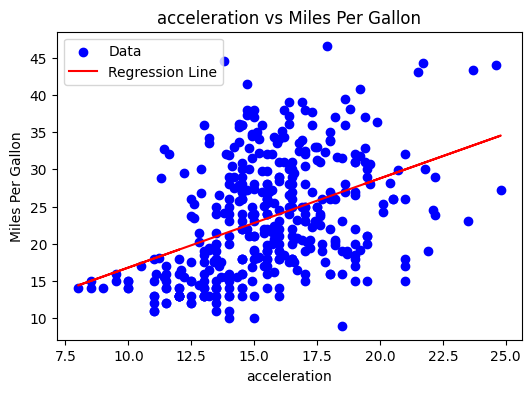

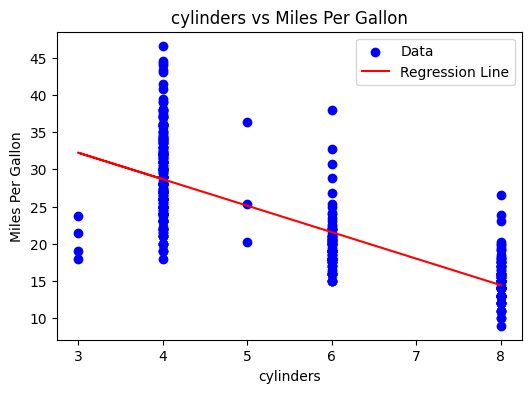

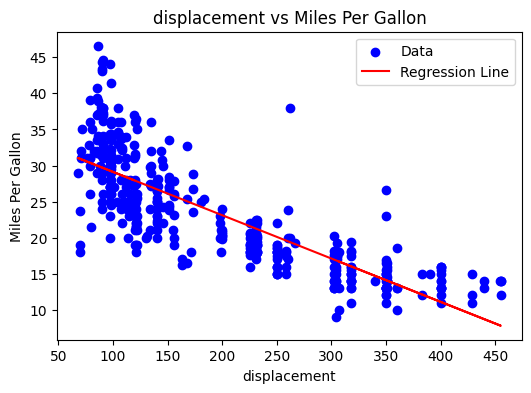

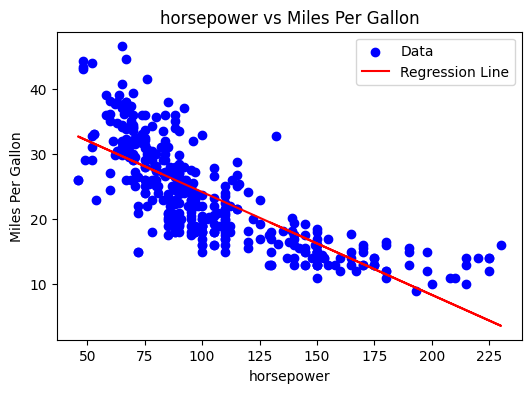

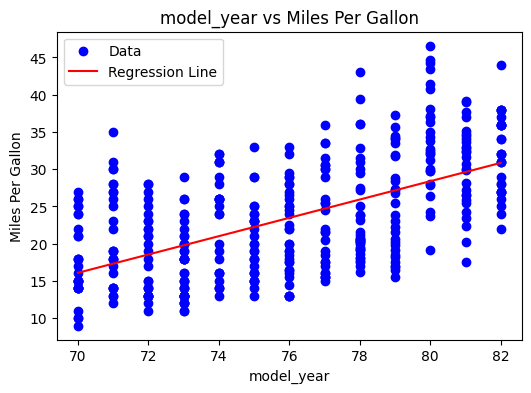

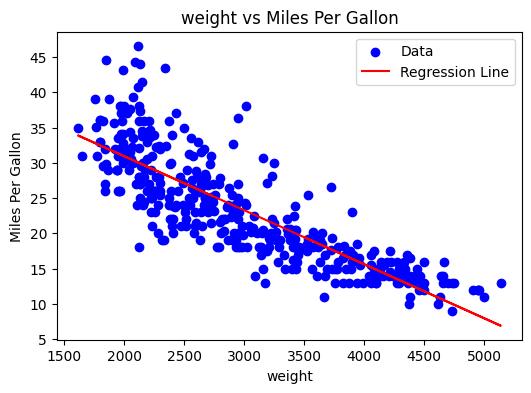

In [45]:
# Exclude the 'mpg' (target variable) and non-numeric columns from the feature names
feature_names = mpg_data.select_dtypes(include=[float, int]).columns.difference(['mpg'])

# Loop through each numeric feature (column) in mpg_data
for feature in feature_names:
    # Extract the feature column and target variable (mpg)
    X_feature = mpg_data[[feature]].values  # Extract as a 2D array
    y = mpg_data['mpg'].values  # Target variable (mpg)
    
    # Create a scatter plot for the feature against the target (mpg)
    plt.figure(figsize=(6, 4))
    plt.scatter(X_feature, y, label='Data', color='blue')

    # Fit a linear regression model
    lm = LinearRegression()
    lm.fit(X_feature, y)

    # Plot the regression line
    plt.plot(X_feature, lm.predict(X_feature), color='red', label='Regression Line')

    # Add labels and title
    plt.xlabel(feature)
    plt.ylabel('Miles Per Gallon')
    plt.title(f'{feature} vs Miles Per Gallon')

    # Add a legend
    plt.legend()

    # Show the plot
    plt.show()

Answer the following questions:

_(i)_ Describe the associations being plotted ? (i.e., positive association, negative association, no association)

1: positive
2. negative
3. negative
4. negative
5. positive
6. negative

_(ii)_ What concept ‘defines’ the plotted line?

A linear regression line

_(iii)_ Do all data points in the dataset fall perfectly along the plotted line? If not, why might there be deviations between the data points and the line, and what do these deviations indicate about the relationship between the variables?

No, most of the data points don't fall on the line. Deviations exists because most of the datapoints are not in the exact same relationship as the regression line. There is variablity in the relationship between data points. The regression line captures the general trend after considering all the data points.

#### **Question 3:**  
#### Model fit  
Now, let’s fit a multivariable linear regression model using the general syntax `lm()`. As above, use **mpg** as the response variable **Y**, and all other variables as the predictors.

**Step 1: Split the dataset into train and test sets, using a 75-25 split. (use random_state=42)**

In [60]:
# print(help(train_test_split))
train,test = train_test_split(mpg_data,train_size=0.75,random_state = 42)
print(len(train),len(test),len(mpg_data),len(train)/len(mpg_data))

294 98 392 0.75


In [369]:
# print(help(mpg_data.drop))
# =====================================
# Changing the predictors to a few variables that are stringly correlated will improve the model accuracy
predictors = mpg_data.drop(["mpg","origin","name"],axis=1).columns.values
# predictors = ["acceleration"]
print(predictors)
print(mpg_data[predictors])

['cylinders' 'displacement' 'horsepower' 'weight' 'acceleration'
 'model_year']
     cylinders  displacement  horsepower  weight  acceleration  model_year
0            8         307.0       130.0    3504          12.0          70
1            8         350.0       165.0    3693          11.5          70
2            8         318.0       150.0    3436          11.0          70
3            8         304.0       150.0    3433          12.0          70
4            8         302.0       140.0    3449          10.5          70
..         ...           ...         ...     ...           ...         ...
393          4         140.0        86.0    2790          15.6          82
394          4          97.0        52.0    2130          24.6          82
395          4         135.0        84.0    2295          11.6          82
396          4         120.0        79.0    2625          18.6          82
397          4         119.0        82.0    2720          19.4          82

[392 rows x 6 colum

**Step 2: Fit the linear regression model.**

In [355]:
# print(train.drop(["mpg","origin","name"],axis=1))
# print(train.columns)
# numeric_predictors = pd.DataFrame(columns = test.drop(["mpg","origin","name"],axis=1).columns)
# print(numeric_predictors)
# print(lm.coef_)
# np.repeat([lm.intercept_],len(lm.coef_[0]))

In [364]:
# Your code here ...
lm = LinearRegression()
numeric_predictors = pd.DataFrame(columns = predictors)
lm.fit(train[predictors],train[["mpg"]])
print(lm.coef_)

print(lm.coef_,lm.intercept_[0])
print(numeric_predictors.columns)
# Create a DataFrame containing the slope (coefficients) and intercept
coefficients_df = pd.DataFrame({
    "predictor": numeric_predictors.columns,
    "slope": lm.coef_[0],
    "intercept": np.repeat([lm.intercept_],len(lm.coef_[0]))
})

# Display the coefficients DataFrame
print(coefficients_df)

# lm.coef_ gives the coefficients for each predictor (change in miles per gallon per unit change in each predictor variable)
# lm.intercept_ gives the intercept b_0 (the predicted miles per gallon when all predictors are set to 0)

[[-1.60142765e-01  3.73447288e-04 -1.89866545e-03 -6.45678716e-03
   5.75878495e-02  7.62270091e-01]]
[[-1.60142765e-01  3.73447288e-04 -1.89866545e-03 -6.45678716e-03
   5.75878495e-02  7.62270091e-01]] -15.047370795059138
Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model_year'],
      dtype='object')
      predictor     slope  intercept
0     cylinders -0.160143 -15.047371
1  displacement  0.000373 -15.047371
2    horsepower -0.001899 -15.047371
3        weight -0.006457 -15.047371
4  acceleration  0.057588 -15.047371
5    model_year  0.762270 -15.047371


In [365]:
min_max_df = mpg_data[predictors].agg(["min","max"]).T
min_max_df["predictor"] = min_max_df.index.values
min_max_df.reset_index(inplace=True)
print(min_max_df)

          index     min     max     predictor
0     cylinders     3.0     8.0     cylinders
1  displacement    68.0   455.0  displacement
2    horsepower    46.0   230.0    horsepower
3        weight  1613.0  5140.0        weight
4  acceleration     8.0    24.8  acceleration
5    model_year    70.0    82.0    model_year


In [366]:
coefficients_df = pd.merge(coefficients_df,min_max_df,on="predictor")
print(coefficients_df)
# print(help(pd.DataFrame.merge))

      predictor     slope  intercept         index     min     max
0     cylinders -0.160143 -15.047371     cylinders     3.0     8.0
1  displacement  0.000373 -15.047371  displacement    68.0   455.0
2    horsepower -0.001899 -15.047371    horsepower    46.0   230.0
3        weight -0.006457 -15.047371        weight  1613.0  5140.0
4  acceleration  0.057588 -15.047371  acceleration     8.0    24.8
5    model_year  0.762270 -15.047371    model_year    70.0    82.0


#### **Question 4:** 
#### RMSPE
**Step 3. Finally, we predict on the test data set to assess how well our model does.** 

We will evaluate our final model's test error measured by RMSPE.

In [367]:
# calculate RSMPE
rmspe = mean_squared_error(test["mpg"],lm.predict(test[predictors]))**(1/2)
print(rmspe)

3.1854749513391574


acceleration
      predictor     slope  intercept         index  min   max
4  acceleration  0.057588 -15.047371  acceleration  8.0  24.8
8.0 -14.586667998659385
24.8 -13.619192126219906
cylinders
   predictor     slope  intercept      index  min  max
0  cylinders -0.160143 -15.047371  cylinders  3.0  8.0
3.0 -15.527799088821592
8.0 -16.328512911759017
displacement
      predictor     slope  intercept         index   min    max
1  displacement  0.000373 -15.047371  displacement  68.0  455.0
68.0 -15.021976379449523
455.0 -14.87745227884775
horsepower
    predictor     slope  intercept       index   min    max
2  horsepower -0.001899 -15.047371  horsepower  46.0  230.0
46.0 -15.13470940597639
230.0 -15.484063849645397
model_year
    predictor    slope  intercept       index   min   max
5  model_year  0.76227 -15.047371  model_year  70.0  82.0
70.0 38.31153560405912
82.0 47.458776701050816
weight
  predictor     slope  intercept   index     min     max
3    weight -0.006457 -15.047371  we

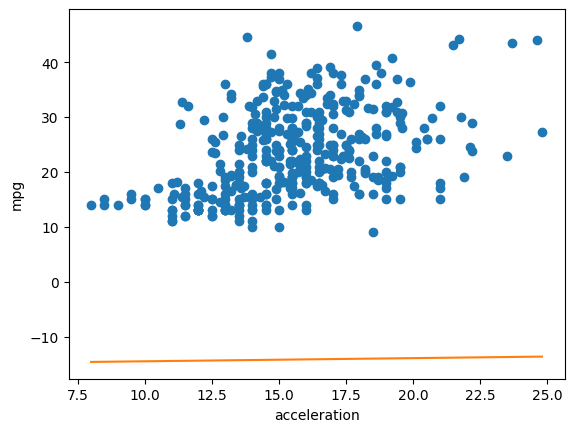

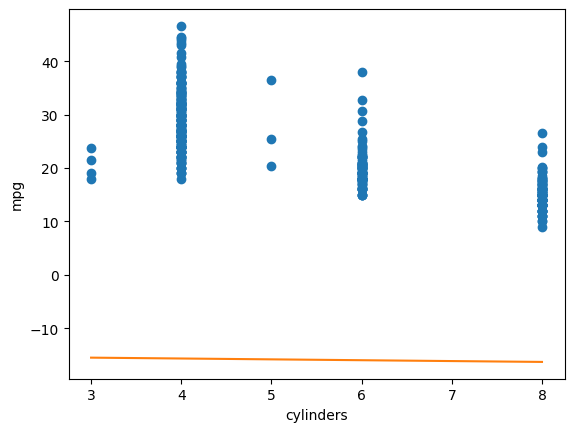

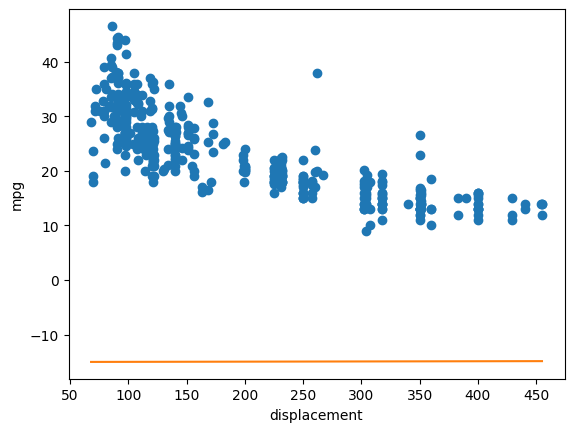

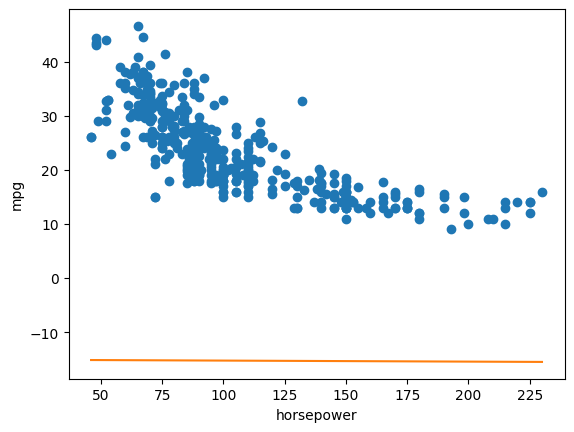

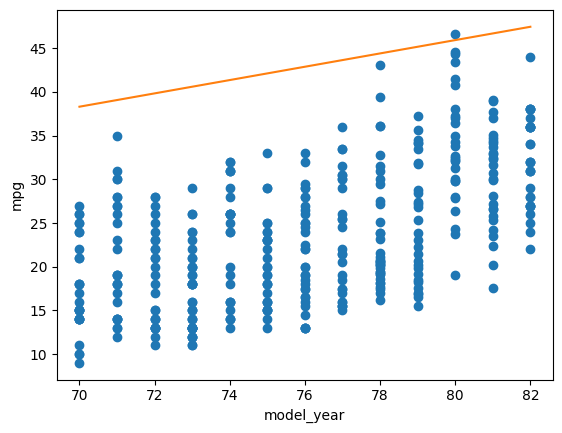

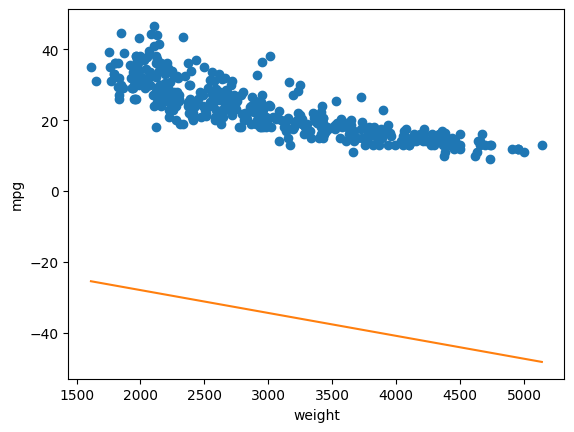

In [368]:
for predictor,row in coefficients_df.groupby(["predictor"]):
    print(predictor[0])
    print(row)
    fh,ax = plt.subplots()
    ax.plot(mpg_data[predictor[0]],mpg_data["mpg"],'o')
    x1 = row["min"].values[0]
    y1 = row["intercept"].values[0] + row["slope"].values[0]*x1
    print(x1,y1)
    x2 = row["max"].values[0]
    y2 = row["intercept"].values[0] + row["slope"].values[0]*x2
    print(x2,y2)
    ax.plot([x1,x2],[y1,y2])
    ax.set_xlabel(predictor[0])
    ax.set_ylabel("mpg")

# Criteria

| **Criteria**                                           | **Complete**                                      | **Incomplete**                                    |
|--------------------------------------------------------|---------------------------------------------------|--------------------------------------------------|
| **Data Inspection**                                    | Data is inspected for the number of variables, observations, and data types. | Data inspection is missing or incomplete.         |
| **Data Visualization**                                 | Visualizations (e.g., scatter plots, histograms) are properly interepreted to explore the relationships between variables. | Data visualization were not correctly interpreted. |
| **Model Initialization**                               | The linear regression model is correctly initialized.            | The linear regression model is not initialized or is incorrect. |
| **Model Evaluation on Test Data**                      | The model is evaluated on the test data using appropriate metrics (e.g., RMSE). | The model evaluation is missing or uses the wrong metric. |


## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Note:

If you like, you may collaborate with others in the cohort. If you choose to do so, please indicate with whom you have worked with in your pull request by tagging their GitHub username. Separate submissions are required.

### Submission Parameters:
* Submission Due Date: `11:59 PM - 05/25/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/LCR/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-6-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
